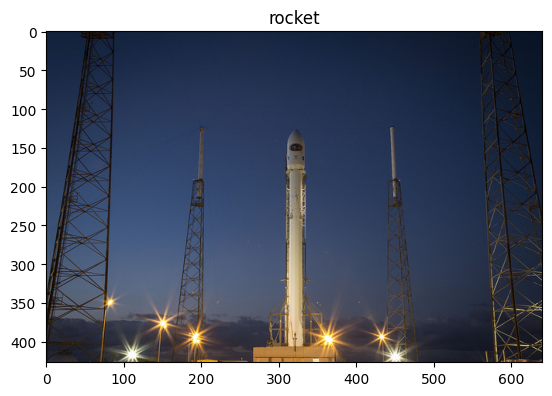

In [3]:
#Task 1: Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import skimage as ski


image_name = 'rocket'
caller = getattr(ski.data, image_name)
image = caller()
plt.figure()
plt.title(image_name)
plt.imshow(image)
plt.show()


In [69]:
#Task 2: Simulate Forward Diffusion

import tensorflow as tf
import torch

# Preprocess the data
def preprocess(img):
    img = tf.cast(img, "float32") / 255.0
    return img

# 1. Define the noise schedule (betas, alphas, alpha_cumprods)
def define_noise_schedule(timesteps):
    # Beta schedule from the original DDPM paper (linear from 1e-4 to 0.02)
    betas = np.linspace(0.0001, 0.02, timesteps, dtype=np.float32)
    # Alpha schedule (1 - beta)
    alphas = 1.0 - betas
    # Cumulative product of alphas
    alpha_hats = np.cumprod(alphas)
    signal_rates = np.sqrt(alpha_hats)
    noise_rates = np.sqrt(1 - alpha_hats)
    return signal_rates, noise_rates

def forward_diffusion(x0, t, signal_rates, noise_rates):

    # Extract signal_rate and noise_rate for the given timestep t
    # t is expected to be an integer representing the time step
    index = int(len(signal_rates) * t)
    signal_rate_t = signal_rates[index]
    noise_rate_t = noise_rates[index]
    print(f"Signal rate and  Noise rate at t={t}: {signal_rate_t}, {noise_rate_t}")

    # Sample noise from a standard normal distribution
    noise = np.random.randn(*x0.shape).astype(np.float32)

    # Apply the forward diffusion equation: x_t = sqrt(alpha_cumprod_t) * x_0 + sqrt(1 - alpha_cumprod_t) * noise
    xt = signal_rate_t * x0 + noise_rate_t * noise
    return xt, noise

def visualize(t_values, t0, tx):
  plt.figure(figsize=(15, 4)) # Adjusted figsize to accommodate more plots horizontally

  # Plot the original image in the first subplot
  plt.subplot(1, len(t_values) + 1, 1) # (rows, cols, index)
  plt.imshow(t0) # Display the original image (unprocessed)
  plt.title('Original (t=0)')
  plt.axis('off')

  # Plot the noised images in subsequent subplots
  for i, t in enumerate(t_values):
      plt.subplot(1, len(t_values) + 1, i + 2) # Subplot index starts from 2
      noised_img_np = tx[i].numpy().squeeze()
      # Normalize the noised image to [0, 1] for proper display with imshow
      min_val = noised_img_np.min()
      max_val = noised_img_np.max()
      if max_val > min_val: # Avoid division by zero if all values are the same
          normalized_img = (noised_img_np - min_val) / (max_val - min_val)
      else:
          normalized_img = np.zeros_like(noised_img_np) # Handle as constant color if all values are same

      plt.imshow(normalized_img) # Display normalized image
      plt.title(f'Noised (t={t})')
      plt.axis('off')

  plt.suptitle('Forward Diffusion Process Simulation') # Overall title for the entire figure
  plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
  plt.show()


Signal rate and  Noise rate at t=0.1: 0.9939361810684204, 0.1099584549665451
Signal rate and  Noise rate at t=0.3: 0.952766478061676, 0.3037038743495941
Signal rate and  Noise rate at t=0.6: 0.8288275599479675, 0.5595041513442993
Signal rate and  Noise rate at t=0.9: 0.6579155325889587, 0.7530916929244995


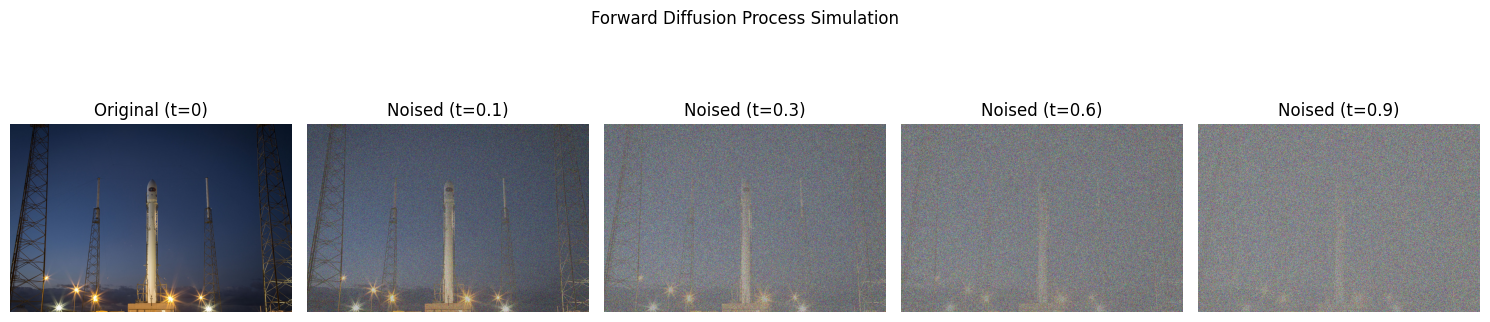

In [70]:
timesteps = 100
signal_rates, noise_rates = define_noise_schedule(timesteps)
initial_data = preprocess(image)

# 2. Simulate diffusion at different timesteps
t_values = [0.1, 0.3, 0.6, 0.9] # Example timesteps
noised_data_points = []
for t in t_values:
    noised_data, _ = forward_diffusion(initial_data, t, signal_rates, noise_rates)
    noised_data_points.append(noised_data)
# 3. Visualization using Matplotlib
visualize(t_values, initial_data, noised_data_points)

In [79]:
#Task 3: Compare Noise Schedules
import math
import numpy as np

def linear_diffusion_schedule(diffusion_times):
    min_rate = 0.0001
    max_rate = 0.02
    betas = min_rate + diffusion_times * (max_rate - min_rate)
    alphas = 1 - betas
    alpha_bars = np.cumprod(alphas, axis=0)
    # Ensure signal_rates and noise_rates are numpy arrays
    signal_rates = np.sqrt(alpha_bars)
    noise_rates = np.sqrt(1 - alpha_bars)
    return signal_rates, noise_rates

def cosine_diffusion_schedule(diffusion_times):
    # Ensure signal_rates and noise_rates are numpy arrays
    signal_rates = np.cos(diffusion_times * math.pi / 2)
    noise_rates = np.sin(diffusion_times * math.pi / 2)
    return signal_rates, noise_rates

diffusion_times = np.linspace(0, 1, timesteps, dtype=np.float32)

Signal rate and  Noise rate at t=0.1: 0.9939361810684204, 0.1099584549665451
Signal rate and  Noise rate at t=0.3: 0.952766478061676, 0.3037038743495941
Signal rate and  Noise rate at t=0.6: 0.8288275599479675, 0.5595041513442993
Signal rate and  Noise rate at t=0.9: 0.6579155921936035, 0.7530916929244995


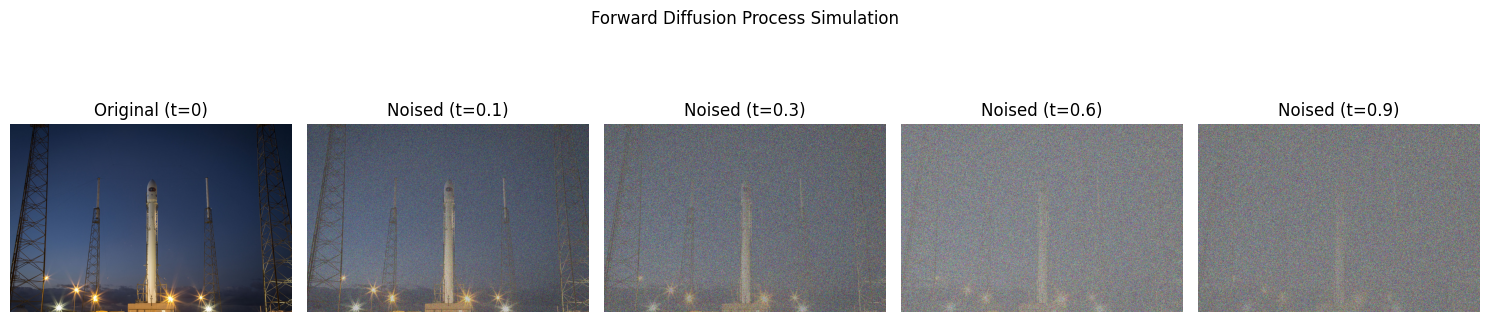

In [80]:
#Apply linear schedule
lnoised_data_points = []
linear_signal_rates, linear_noise_rates = linear_diffusion_schedule(diffusion_times)
for t in t_values:
    noised_data, _ = forward_diffusion(initial_data, t, linear_signal_rates, linear_noise_rates)
    lnoised_data_points.append(noised_data)
visualize(t_values, initial_data, lnoised_data_points)

Signal rate and  Noise rate at t=0.1: 0.9874389171600342, 0.1580013930797577
Signal rate and  Noise rate at t=0.3: 0.8888354301452637, 0.4582265317440033
Signal rate and  Noise rate at t=0.6: 0.5800568461418152, 0.8145759701728821
Signal rate and  Noise rate at t=0.9: 0.14231474697589874, 0.9898214340209961


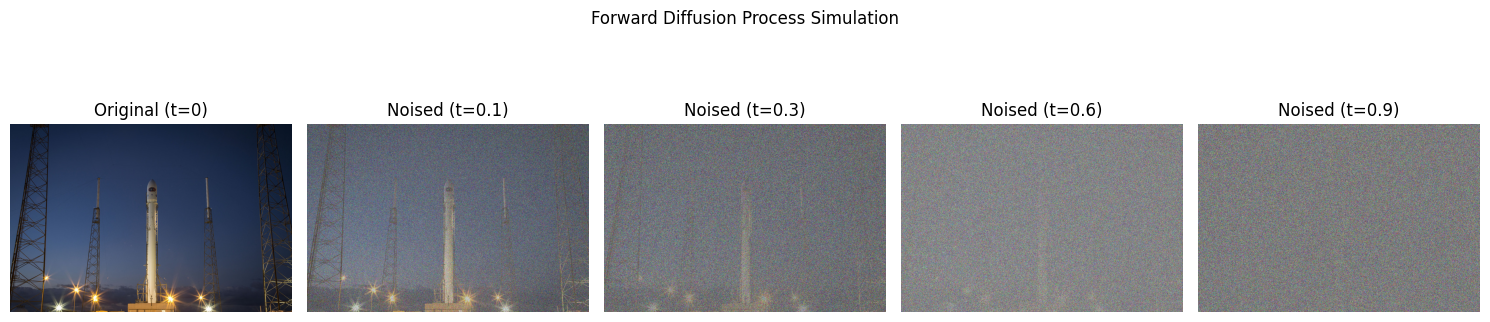

In [81]:
#Apply cosine schedule
cnoised_data_points = []
cosine_signal_rates, cosine_noise_rates = cosine_diffusion_schedule(diffusion_times)
for t in t_values:
    noised_data, _ = forward_diffusion(initial_data, t, cosine_signal_rates, cosine_noise_rates)
    cnoised_data_points.append(noised_data)
visualize(t_values, initial_data, cnoised_data_points)

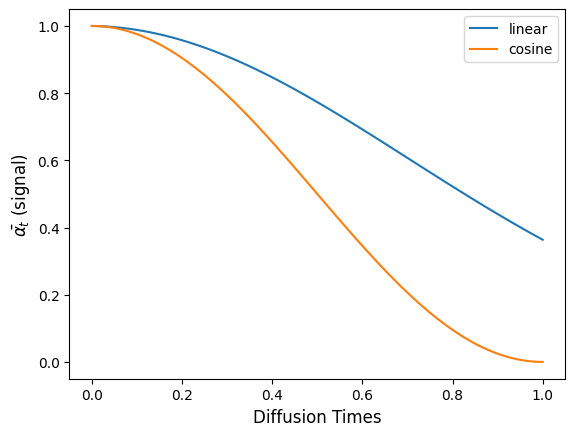

In [83]:
plt.plot(
    diffusion_times, linear_signal_rates**2, linewidth=1.5, label="linear"
)
plt.plot(
    diffusion_times, cosine_signal_rates**2, linewidth=1.5, label="cosine"
)
plt.xlabel("Diffusion Times", fontsize=12)
plt.ylabel(r"$\bar{\alpha_t}$ (signal)", fontsize=12)
plt.legend()
plt.show()

# Analysis

The cosine schedule is adding more noise as the timesteps progress. By timestep 0.6 the original image is almost hidden by noise. Linear schedule is adding noise more gradually. By timestep 0.9 the original image is almost invisible. The linear plot above shows the same. For Cosine signal is nearing to 0 whereas for linear it stands around 0.4

#Optional
VAE's and GAN's convert original image into a latent space, a compressed representation of the original and then regenerate from that compressed latent space variations. The approach in diffusion models is very different. Diffusion models by adding noise gradually, learn what constitutes noise and what data points/pixels actually make up the image making it more refined with sharp features, elevating the colour, sharpness and clarity.